<a href="https://colab.research.google.com/github/AnuskaDey07/Pixora/blob/main/background_removal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:

%pip install --force-reinstall "numpy==2.2.6" "rembg[cpu]"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
  Using cached rembg-2.0.85-py3-none-any.whl.metadata (26 kB)
INFO: pip is looking at multiple versions of rembg[cpu] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of rembg[cpu] to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached pillow-12.3.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pymatting-1.1.16-py3-none-any.whl.metadata (9.1 kB)
  Using cached scikit_image-0.26.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:

import numpy as np
print("NumPy:", np.__version__)

import onnxruntime as ort
print("ONNX Runtime:", ort.__version__)

from rembg import remove
print("rembg imported successfully!")


NumPy: 2.2.6
ONNX Runtime: 1.31.0
rembg imported successfully!


In [6]:

from google.colab import files

uploaded = files.upload()
input_path = next(iter(uploaded))

print("Uploaded image:", input_path)


Saving istockphoto-1399565382-612x612.jpg to istockphoto-1399565382-612x612.jpg
Uploaded image: istockphoto-1399565382-612x612.jpg


Background removed successfully!


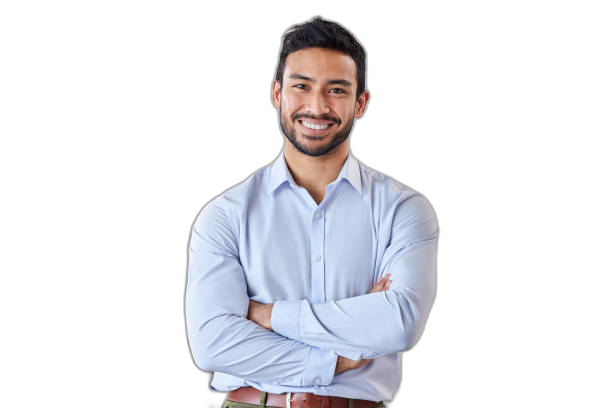

In [7]:

from rembg import remove
from PIL import Image
from IPython.display import display
from pathlib import Path

input_image = Image.open(input_path).convert("RGBA")

output_image = remove(input_image)

output_path = str(
    Path(input_path).with_name(
        Path(input_path).stem + "_no_background.png"
    )
)

output_image.save(output_path)

print("Background removed successfully!")
display(output_image)


In [8]:

%%writefile background_removal.py

from pathlib import Path
from PIL import Image
from rembg import remove


def remove_background(image_path, output_dir="outputs"):
    """
    Remove an image background and save a transparent PNG.
    Returns the output file path.
    """
    image_path = Path(image_path)

    if not image_path.is_file():
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    with Image.open(image_path) as image:
        image = image.convert("RGBA")
        result = remove(image)

    output_path = output_dir / f"{image_path.stem}_no_background.png"
    result.save(output_path, format="PNG")

    return str(output_path)


Writing background_removal.py


Saved to: outputs/istockphoto-1399565382-612x612_no_background.png


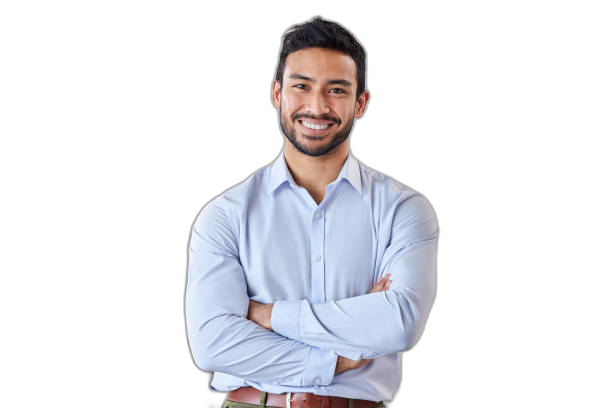

In [9]:

from background_removal import remove_background
from IPython.display import display
from PIL import Image

output_path = remove_background(input_path)

print("Saved to:", output_path)

display(Image.open(output_path))
